# 稠密连接网络（DenseNet）

ResNet极大地改变了如何参数化深层网络中函数的观点。
*稠密连接网络*（DenseNet） :cite:`Huang.Liu.Van-Der-Maaten.ea.2017`在某种程度上是ResNet的逻辑扩展。让我们先从数学上了解一下。

## 从ResNet到DenseNet

回想一下任意函数的泰勒展开式（Taylor expansion），它把这个函数分解成越来越高阶的项。在$x$接近0时，

$$f(x) = f(0) + f'(0) x + \frac{f''(0)}{2!}  x^2 + \frac{f'''(0)}{3!}  x^3 + \ldots.$$

同样，ResNet将函数展开为

$$f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x}).$$

也就是说，ResNet将$f$分解为两部分：一个简单的线性项和一个复杂的非线性项。
那么再向前拓展一步，如果我们想将$f$拓展成超过两部分的信息呢？
一种方案便是DenseNet。

![ResNet（左）与 DenseNet（右）在跨层连接上的主要区别：使用相加和使用连结。](../img/densenet-block.svg)
:label:`fig_densenet_block`

如 :numref:`fig_densenet_block`所示，ResNet和DenseNet的关键区别在于，DenseNet输出是*连接*（用图中的$[,]$表示）而不是如ResNet的简单相加。
因此，在应用越来越复杂的函数序列后，我们执行从$\mathbf{x}$到其展开式的映射：

$$\mathbf{x} \to \left[
\mathbf{x},
f_1(\mathbf{x}),
f_2([\mathbf{x}, f_1(\mathbf{x})]), f_3([\mathbf{x}, f_1(\mathbf{x}), f_2([\mathbf{x}, f_1(\mathbf{x})])]), \ldots\right].$$

最后，将这些展开式结合到多层感知机中，再次减少特征的数量。
实现起来非常简单：我们不需要添加术语，而是将它们连接起来。
DenseNet这个名字由变量之间的“稠密连接”而得来，最后一层与之前的所有层紧密相连。
稠密连接如 :numref:`fig_densenet`所示。

![稠密连接。](../img/densenet.svg)
:label:`fig_densenet`

稠密网络主要由2部分构成：*稠密块*（dense block）和*过渡层*（transition layer）。
前者定义如何连接输入和输出，而后者则控制通道数量，使其不会太复杂。

## (**稠密块体**)

DenseNet使用了ResNet改良版的“批量规范化、激活和卷积”架构（参见 :numref:`sec_resnet`中的练习）。
我们首先实现一下这个架构。


In [1]:
%pip install d2l==1.0.3 --no-deps
%pip install scipy torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 5.4 MB/s eta 0:00:00


In [2]:
import torch
from torch import nn
from d2l import torch as d2l


def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1))

In [3]:
import torch
from torch import nn
from d2l import torch as d2l


def conv_block_bottle_neck(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.BatchNorm2d(num_channels), nn.ReLU(),
        nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1))

一个*稠密块*由多个卷积块组成，每个卷积块使用相同数量的输出通道。
然而，在前向传播中，我们将每个卷积块的输入和输出在通道维上连结。


In [4]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                # 动态计算每个卷积块的输入通道数
                # 第 0 个卷积块的输入是最初的 input_channels。
                # 第 1 个卷积块的输入是 最初通道数 + 1次增长率。
                # 第 2 个卷积块的输入是 最初通道数 + 2次增长率。
                num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

In [5]:
class DenseBlockBottleNeck(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlockBottleNeck, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block_bottle_neck(
                # 动态计算每个卷积块的输入通道数
                # 第 0 个卷积块的输入是最初的 input_channels。
                # 第 1 个卷积块的输入是 最初通道数 + 1次增长率。
                # 第 2 个卷积块的输入是 最初通道数 + 2次增长率。
                num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

在下面的例子中，我们[**定义一个**]有2个输出通道数为10的(**`DenseBlock`**)。
使用通道数为3的输入时，我们会得到通道数为$3+2\times 10=23$的输出。
卷积块的通道数控制了输出通道数相对于输入通道数的增长，因此也被称为*增长率*（growth rate）。


In [6]:
blk = DenseBlockBottleNeck(2, 3, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

## [**过渡层**]

由于每个稠密块都会带来通道数的增加，使用过多则会过于复杂化模型。
而过渡层可以用来控制模型复杂度。
它通过$1\times 1$卷积层来减小通道数，并使用步幅为2的平均汇聚层减半高和宽，从而进一步降低模型复杂度。


In [7]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

对上一个例子中稠密块的输出[**使用**]通道数为10的[**过渡层**]。
此时输出的通道数减为10，高和宽均减半。


In [8]:
blk = transition_block(23, 10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

## [**DenseNet模型**]

我们来构造DenseNet模型。DenseNet首先使用同ResNet一样的单卷积层和最大汇聚层。


In [9]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

接下来，类似于ResNet使用的4个残差块，DenseNet使用的是4个稠密块。
与ResNet类似，我们可以设置每个稠密块使用多少个卷积层。
这里我们设成4，从而与 :numref:`sec_resnet`的ResNet-18保持一致。
稠密块里的卷积层通道数（即增长率）设为32，所以每个稠密块将增加128个通道。

在每个模块之间，ResNet通过步幅为2的残差块减小高和宽，DenseNet则使用过渡层来减半高和宽，并减半通道数。


In [13]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [6, 12, 24, 16]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlockBottleNeck(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

与ResNet类似，最后接上全局汇聚层和全连接层来输出结果。


In [14]:
net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

## [**训练模型**]

由于这里使用了比较深的网络，本节里我们将输入高和宽从224降到96来简化计算。


loss 0.136, train acc 0.952, test acc 0.888
686.2 examples/sec on cuda:0


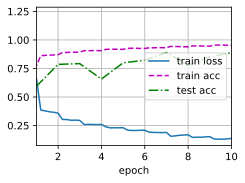

In [16]:
lr, num_epochs, batch_size = 0.05, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 小结

* 在跨层连接上，不同于ResNet中将输入与输出相加，稠密连接网络（DenseNet）在通道维上连结输入与输出。
* DenseNet的主要构建模块是稠密块和过渡层。
* 在构建DenseNet时，我们需要通过添加过渡层来控制网络的维数，从而再次减少通道的数量。

## 练习

1. 为什么我们在过渡层使用平均汇聚层而不是最大汇聚层？
1. DenseNet的优点之一是其模型参数比ResNet小。为什么呢？
1. DenseNet一个诟病的问题是内存或显存消耗过多。
    1. 真的是这样吗？可以把输入形状换成$224 \times 224$，来看看实际的显存消耗。
    1. 有另一种方法来减少显存消耗吗？需要改变框架么？
1. 实现DenseNet论文 :cite:`Huang.Liu.Van-Der-Maaten.ea.2017`表1所示的不同DenseNet版本。
1. 应用DenseNet的思想设计一个基于多层感知机的模型。将其应用于 :numref:`sec_kaggle_house`中的房价预测任务。


[Discussions](https://discuss.d2l.ai/t/1880)


**第一问**  
### 1. 核心理念的契合：完整保留特征 vs. 丢弃特征
* **DenseNet 的灵魂是“特征复用”**。通过密集的通道拼接，网络极其珍视前面每一层提取出来的无论是底层纹理还是高层语义信息。
* **最大汇聚层（Max Pooling）的本质是“特征选择”**。在一个 $2 \times 2$ 的窗口里，它只保留那个最强的信号（最大值），而把其余 75% 的信息直接丢弃。这会破坏 DenseNet 好不容易累积起来的密集特征。
* **平均汇聚层（Average Pooling）则是“特征融合”**。它将窗口内所有的信息取平均，这意味着**所有**的历史特征都参与了下采样过程，没有人被完全丢弃。这与 DenseNet “物尽其用”的设计哲学完美契合。
### 2. 起到平滑与正则化的作用
* 随着 DenseBlock 不断拼接通道，特征图中可能会积累很多极端的“尖峰”噪声（某些局部的激活值过大）。
* 最大汇聚层会进一步放大这些极端噪声（因为它专挑大的选）。而平均汇聚层相当于做了一次低通滤波（Low-pass filtering），能有效平滑这些特征，降低模型的方差，起到一定的**正则化效果**，帮助原本就容易过拟合（就像您上一张图中看到的那样）的深层网络提升泛化能力。

**第二问**  
因为densenet网络复用了前面网络的特征图，所以每一个稠密块的输出通道都是固定的(例如32或者64)，尽管输入通道因为叠加的原因，比resnet网络更大，但是通过$1 \times 1$ 卷积降维之后，到了$3 \times 3$ 卷积之后，输入通道数就和resnet没有区别，甚至更少（参数量的主要贡献就是$3 \times 3$ 卷积），但是densenet$3 \times 3$ 卷积的输出通道数少得多，所以导致densenet参数量更少。

**第三问**  
有非常完美的解决方案，且完全不需要改变或重写底层框架。  
梯度检查点（时间换空间）：前向传播时，只在特定的层（也就是“检查点”）保存激活值，中间层计算完就把激活值从显存里删掉（释放掉 concat 产生的巨大张量）。当反向传播需要用到那些被删掉的激活值时，就从最近的“检查点”出发，重新计算一次（Recompute）前向传播来获得它。
在 PyTorch 中，只需使用 torch.utils.checkpoint.checkpoint 函数包裹你的稠密块代码。

**第四问**  
原来的结果如下：  
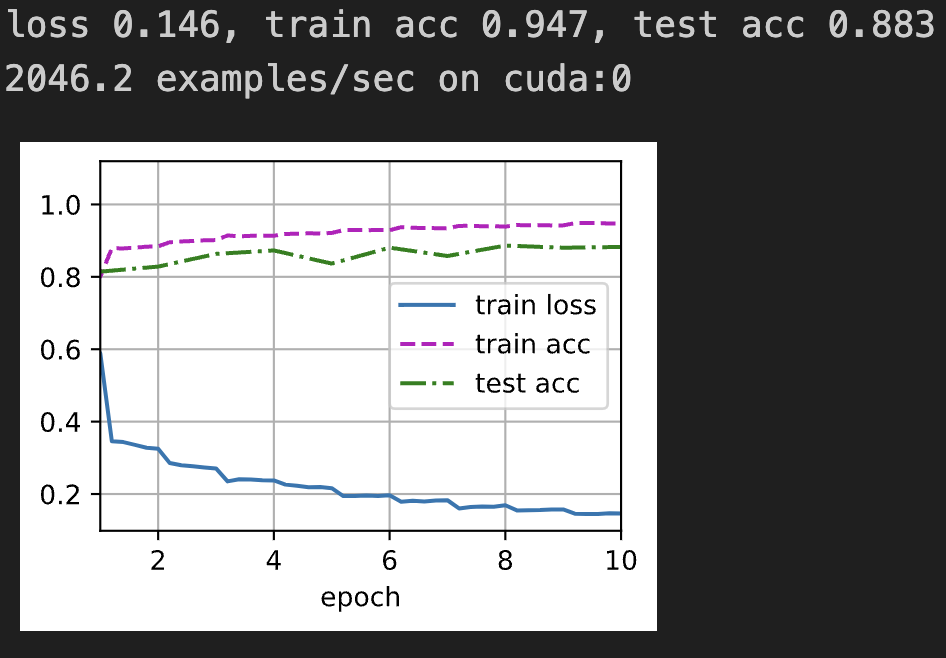  
densenet-121的结果如下：  
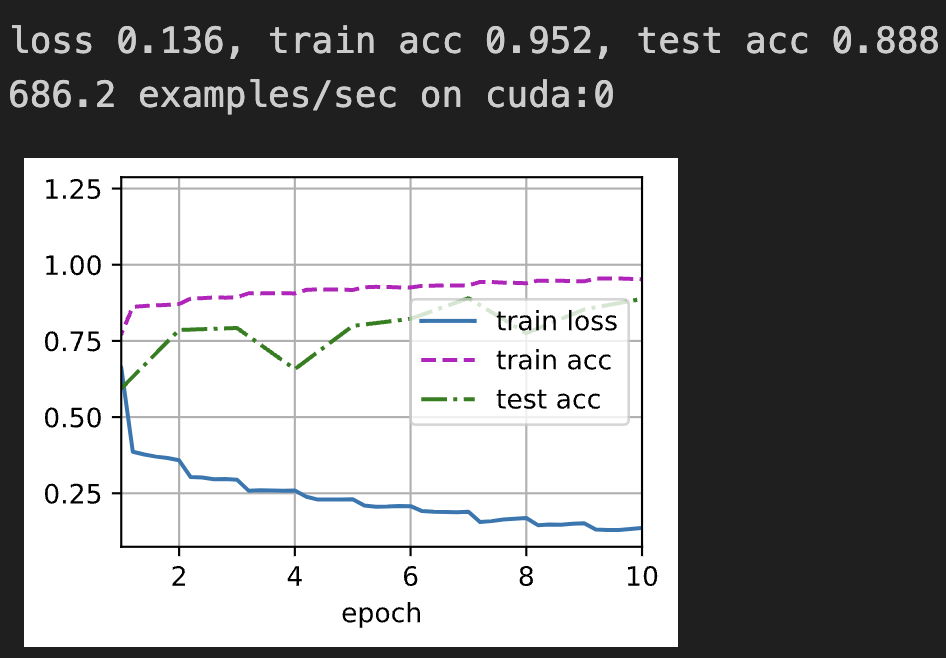

In [18]:
# 第五问
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

# 下载并加载数据 (沿用 d2l 的内置函数)
def download_data():
    DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'
    train_data = pd.read_csv(DATA_URL + 'kaggle_house_pred_train.csv')
    test_data = pd.read_csv(DATA_URL + 'kaggle_house_pred_test.csv')
    return train_data, test_data

train_data, test_data = download_data()

# 数据预处理：去掉第一列 Id
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

# 1. 数值特征标准化 (减去均值，除以标准差)
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0) # 缺失值填充为 0

# 2. 离散特征 One-Hot 编码
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features = all_features * 1 # 将 boolean 转换为 0/1

# 3. 转换为 PyTorch 张量
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

in_features = train_features.shape[1]
print(f"预处理完毕，输入特征维度 (in_features): {in_features}")

# 定义模型
class DenseMLPBlock(nn.Module):
    def __init__(self, num_layers, input_dim, growth_rate):
        super(DenseMLPBlock, self).__init__()
        self.layers = nn.ModuleList()
        current_dim = input_dim
        
        for _ in range(num_layers):
            self.layers.append(nn.Sequential(
                nn.Linear(current_dim, growth_rate),
                nn.ReLU()
            ))
            current_dim += growth_rate

    def forward(self, X):
        for layer in self.layers:
            Y = layer(X)
            X = torch.cat([X, Y], dim=1) # 在特征维度进行拼接
        return X

def get_dense_net():
    num_layers = 3      # 稠密块中的网络层数
    growth_rate = 16    # 每一层提取的新特征数 (增长率)
    final_dim = in_features + num_layers * growth_rate
    
    net = nn.Sequential(
        DenseMLPBlock(num_layers, in_features, growth_rate),
        nn.Linear(final_dim, 1) # 最终的回归输出层
    )
    return net

loss = nn.MSELoss()

def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于 1 的值设置为 1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

def train(net, train_features, train_labels, test_features, test_labels, 
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    
    # 使用 Adam 优化器，它对这种深层拼接网络表现更好
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_dense_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        print(f'折 {i + 1}，训练 log rmse {float(train_ls[-1]):f}, '
              f'验证 log rmse {float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

# 超参数设置 (您可以自行微调)
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 0.05, 0.001, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)
print(f'{k}-折验证: 平均训练 log rmse: {float(train_l):f}, 平均验证 log rmse: {float(valid_l):f}')

预处理完毕，输入特征维度 (in_features): 330
折 1，训练 log rmse 0.083477, 验证 log rmse 0.158048
折 2，训练 log rmse 0.135934, 验证 log rmse 0.252844
折 3，训练 log rmse 0.067942, 验证 log rmse 0.160863
折 4，训练 log rmse 0.080985, 验证 log rmse 0.132447
折 5，训练 log rmse 0.090221, 验证 log rmse 0.162358
5-折验证: 平均训练 log rmse: 0.091712, 平均验证 log rmse: 0.173312
